# ME 3300 Lab 09 — Propeller Thrust Stand: Solution Notebook (TA)

**TA use only.** Runs against the synthetic data in `../Data/` (regenerate
with `generate_synthetic_data.py`). Executing this notebook validates every
code block in the Lab 09 manual — the figures it saves into `../Figures/`
ARE the manual's example figures.

Part numbering mirrors the manual. Parts 1–2 (wiring, arming, first spin)
are hardware-only; the analysis begins at Part 3.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif']
plt.rcParams['font.size'] = 10

date_str = '2026-11-10'   # students: use your lab date

## Part-3: Dead-Weight Calibration of the Load-Cell Chain

Prop OFF. Masses on the platform load the cell exactly like thrust does.
The calibration maps amplifier output volts → force in newtons, fit as
$F = c_1 V + c_0$ so sweep voltages convert directly to thrust.

In [2]:
cal = np.loadtxt('../Data/loadcell_calibration_data.csv',
                 delimiter=',', comments='#')
masses_g = cal[:, 0]
volts    = cal[:, 1]
force_N  = masses_g / 1000 * 9.81          # grams -> kg -> newtons

coeffs = np.polyfit(volts, force_N, 1)     # F = c1*V + c0
print(f"c1 = {coeffs[0]:.4f} N/V, c0 = {coeffs[1]:.4f} N")

c1 = 9.8920 N/V, c0 = -0.8839 N


In [3]:
resid  = force_N - np.polyval(coeffs, volts)
nu     = len(volts) - 2                    # 5 points, 2 fit parameters
norm_r = np.sqrt(np.sum(resid**2))
s_yx   = norm_r / np.sqrt(nu)
t_val  = stats.t.ppf(0.975, df=nu)         # two-sided 95% => 0.975!
CI     = t_val * s_yx
S_c1   = s_yx / np.sqrt(np.sum((volts - volts.mean())**2))

print(f"norm = {norm_r:.4f} N, s_yx = {s_yx:.4f} N, "
      f"95% CI = {CI:.4f} N, S_c1 = {S_c1:.4f} N/V")

# Save the coefficients — Lab 10 reuses this calibration
np.savetxt('../Data/loadcell_calibration_coeffs.csv', coeffs,
           header='c1 (N/V), c0 (N)', delimiter=',')

norm = 0.0025 N, s_yx = 0.0015 N, 95% CI = 0.0047 N, S_c1 = 0.0037 N/V


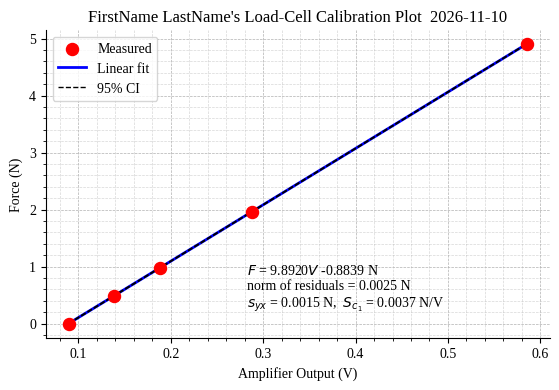

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4.0), facecolor='white')

ax.scatter(volts, force_N, s=75, c='red', zorder=3, label='Measured')
v_fit = np.linspace(volts.min(), volts.max(), 100)
ax.plot(v_fit, np.polyval(coeffs, v_fit), 'b-', lw=2, label='Linear fit')
ax.plot(v_fit, np.polyval(coeffs, v_fit) + CI, 'k--', lw=1, label='95% CI')
ax.plot(v_fit, np.polyval(coeffs, v_fit) - CI, 'k--', lw=1)

ax.set_xlabel('Amplifier Output (V)')
ax.set_ylabel('Force (N)')
ax.set_title(f"FirstName LastName's Load-Cell Calibration Plot  {date_str}")
ax.grid(which='major', ls='--', lw=0.5)
ax.grid(which='minor', ls='--', lw=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left')
ax.text(0.40, 0.10,
        f"$F$ = {coeffs[0]:.4f}$V$ {coeffs[1]:+.4f} N\n"
        f"norm of residuals = {norm_r:.4f} N\n"
        f"$s_{{yx}}$ = {s_yx:.4f} N,  $S_{{c_1}}$ = {S_c1:.4f} N/V",
        transform=ax.transAxes)

fig.savefig('../Figures/FirstName_LastName_Lab09_LoadCellCalibration.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab09_LoadCellCalibration.pdf',
            bbox_inches='tight')
plt.show()

## Part-4/5: Load the Sweep Data

Six files: 2 propellers × 3 repeated sweeps. A dictionary keyed by
propeller name keeps the two datasets organized; `np.stack` turns each
propeller's three runs into one 3-D array so run statistics are one
`axis=0` reduction.

In [5]:
tare = np.loadtxt('../Data/TareRecording.csv', delimiter=',', comments='#')
v_tare = tare[:, 1].mean()                 # motor-off cell voltage
print(f"tare voltage = {v_tare:.4f} V")

props = ['PropA', 'PropB']
data = {}                                  # dictionary: one entry per prop

for prop in props:
    runs = [np.loadtxt(f'../Data/ThrustSweep_{prop}_Run{r}.csv',
                       delimiter=',', comments='#') for r in (1, 2, 3)]
    arr = np.stack(runs)                   # shape (3 runs, 13 setpoints, 3 cols)

    throttle = arr[0, :, 0]                # same setpoints every run
    thrust_N = (np.polyval(coeffs, arr[:, :, 1])
                - np.polyval(coeffs, v_tare))       # tare-corrected
    current_A = (arr[:, :, 2] - 2.5) / 0.100        # ACS712-20A datasheet

    data[prop] = {'throttle': throttle, 'T': thrust_N, 'I': current_A}
    print(prop, 'thrust array shape:', thrust_N.shape)

tare voltage = 0.0893 V
PropA thrust array shape: (3, 13)
PropB thrust array shape: (3, 13)


## Part-5: Thrust Curves with Confidence Intervals

Three runs at each setpoint → a mean, a standard deviation, and a 95%
confidence interval on the mean ($\nu = 2$, so $t_{2,95\%} = 4.303$ — small
samples are expensive!).

In [6]:
t2 = stats.t.ppf(0.975, df=2)
for prop in props:
    d = data[prop]
    d['T_mean'] = d['T'].mean(axis=0)
    d['T_CI']   = t2 * d['T'].std(axis=0, ddof=1) / np.sqrt(3)
    d['I_mean'] = d['I'].mean(axis=0)
    d['I_CI']   = t2 * d['I'].std(axis=0, ddof=1) / np.sqrt(3)
    print(f"{prop}: max thrust {d['T_mean'][-1]/9.81*1000:.0f} g, "
          f"CI at 70% = ±{d['T_CI'][-1]/9.81*1000:.1f} g")

PropA: max thrust 184 g, CI at 70% = ±1.7 g
PropB: max thrust 220 g, CI at 70% = ±6.4 g


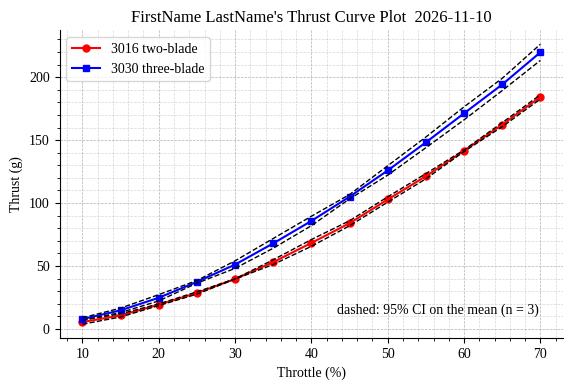

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.0), facecolor='white')

styles = {'PropA': ('red', 'o', '3016 two-blade'),
          'PropB': ('blue', 's', '3030 three-blade')}
for prop in props:
    d = data[prop]
    c, m, lab = styles[prop]
    g = d['T_mean'] / 9.81 * 1000          # newtons -> grams-force
    gCI = d['T_CI'] / 9.81 * 1000
    ax.plot(d['throttle'], g, '-', c=c, lw=1.5, marker=m, ms=5, label=lab)
    ax.plot(d['throttle'], g + gCI, 'k--', lw=1)
    ax.plot(d['throttle'], g - gCI, 'k--', lw=1)

ax.set_xlabel('Throttle (%)')
ax.set_ylabel('Thrust (g)')
ax.set_title(f"FirstName LastName's Thrust Curve Plot  {date_str}")
ax.grid(which='major', ls='--', lw=0.5)
ax.grid(which='minor', ls='--', lw=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left')
ax.text(0.55, 0.08, 'dashed: 95% CI on the mean (n = 3)',
        transform=ax.transAxes)

fig.savefig('../Figures/FirstName_LastName_Lab09_ThrustCurves.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab09_ThrustCurves.pdf',
            bbox_inches='tight')
plt.show()

## Part-5: Current Draw and Hover Efficiency

Efficiency in grams of thrust per electrical watt is THE figure of merit a
drone designer optimizes: it is flight time. $P = V_{bus} I$ with
$V_{bus} = 12.0$ V nominal.

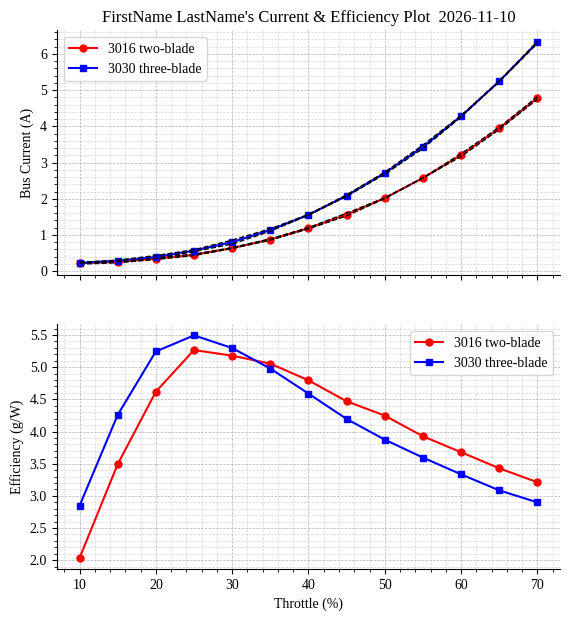

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 7.0),
                               facecolor='white', sharex=True)

for prop in props:
    d = data[prop]
    c, m, lab = styles[prop]
    ax1.plot(d['throttle'], d['I_mean'], '-', c=c, lw=1.5,
             marker=m, ms=5, label=lab)
    ax1.plot(d['throttle'], d['I_mean'] + d['I_CI'], 'k--', lw=1)
    ax1.plot(d['throttle'], d['I_mean'] - d['I_CI'], 'k--', lw=1)

    P = 12.0 * d['I_mean']                          # electrical watts
    eff = (d['T_mean'] / 9.81 * 1000) / P           # g per watt
    ax2.plot(d['throttle'], eff, '-', c=c, lw=1.5, marker=m, ms=5, label=lab)

ax1.set_ylabel('Bus Current (A)')
ax2.set_ylabel('Efficiency (g/W)')
ax2.set_xlabel('Throttle (%)')
ax1.set_title(f"FirstName LastName's Current & Efficiency Plot  {date_str}")
for ax in (ax1, ax2):
    ax.grid(which='major', ls='--', lw=0.5)
    ax.grid(which='minor', ls='--', lw=0.5, alpha=0.5)
    ax.minorticks_on()
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='best')

fig.savefig('../Figures/FirstName_LastName_Lab09_CurrentEfficiency.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab09_CurrentEfficiency.pdf',
            bbox_inches='tight')
plt.show()

## Part-5: Momentum-Theory Fit

Ideal momentum theory: $P_{ideal} = T^{3/2}/\sqrt{2\rho A}$. Plotting
measured electrical power against $T^{3/2}$ should be close to a line; its
slope, compared against the ideal slope $1/\sqrt{2\rho A}$, gives the
system figure of merit $FM = P_{ideal}/P_{elec}$.

ideal slope = 9.54 W/N^1.5
PropA: slope = 22.47 W/N^1.5, intercept = 2.08 W, FM = 0.425
PropB: slope = 23.14 W/N^1.5, intercept = 1.47 W, FM = 0.412


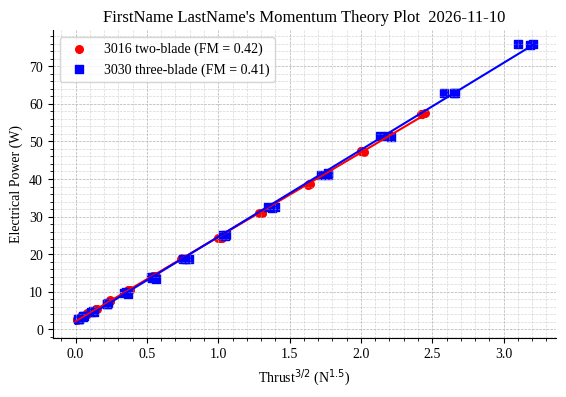

In [9]:
rho = 1.204                    # kg/m^3, sea-level 20 C
A = np.pi * (0.0381)**2        # 3-inch prop disk area, m^2
slope_ideal = 1 / np.sqrt(2 * rho * A)
print(f"ideal slope = {slope_ideal:.2f} W/N^1.5")

fig, ax = plt.subplots(figsize=(6.5, 4.0), facecolor='white')

for prop in props:
    d = data[prop]
    c, m, lab = styles[prop]
    T15 = d['T'].flatten() ** 1.5          # all runs, all setpoints
    P   = 12.0 * d['I'].flatten()
    pc  = np.polyfit(T15, P, 1)
    FM  = slope_ideal / pc[0]
    d['FM'] = FM

    ax.scatter(T15, P, s=30, c=c, marker=m, label=f'{lab} (FM = {FM:.2f})')
    x = np.linspace(0, T15.max(), 50)
    ax.plot(x, np.polyval(pc, x), '-', c=c, lw=1.5)
    print(f"{prop}: slope = {pc[0]:.2f} W/N^1.5, intercept = {pc[1]:.2f} W,"
          f" FM = {FM:.3f}")

ax.set_xlabel('Thrust$^{3/2}$ (N$^{1.5}$)')
ax.set_ylabel('Electrical Power (W)')
ax.set_title(f"FirstName LastName's Momentum Theory Plot  {date_str}")
ax.grid(which='major', ls='--', lw=0.5)
ax.grid(which='minor', ls='--', lw=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left')

fig.savefig('../Figures/FirstName_LastName_Lab09_MomentumFit.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab09_MomentumFit.pdf',
            bbox_inches='tight')
plt.show()

## Part-6: The Hover Design Point

Design brief: a 240 g quadcopter using four of these motors with the prop
YOU choose. Each motor must hold up 60 g at hover. From the measured curve:
what throttle, how much control margin, what current, what flight time on
an 850 mAh battery?

In [10]:
m_quad = 0.240                          # kg, all-up weight
F_hover = m_quad * 9.81 / 4             # N per motor
print(f"hover thrust per motor = {F_hover:.4f} N "
      f"({F_hover/9.81*1000:.1f} g)")

for prop in props:
    d = data[prop]
    thr, Tm, TCI = d['throttle'], d['T_mean'], d['T_CI']

    # interpolate the throttle where mean thrust crosses F_hover
    delta_h = np.interp(F_hover, Tm, thr)

    # thrust CI at that throttle -> throttle uncertainty via local slope
    ci_h    = np.interp(delta_h, thr, TCI)
    slope_h = np.gradient(Tm, thr)[np.argmin(np.abs(thr - delta_h))]
    dthr    = ci_h / slope_h

    I_h  = np.interp(delta_h, thr, d['I_mean'])
    marg = d['T_mean'][-1] / F_hover
    t_fly = 0.850 / (4 * I_h) * 60      # 850 mAh pack, 4 motors, minutes

    print(f"{prop}: hover at {delta_h:.1f} ± {dthr:.1f} %throttle, "
          f"I = {I_h:.2f} A/motor, thrust margin {marg:.2f}x, "
          f"ideal flight time {t_fly:.1f} min")

hover thrust per motor = 0.5886 N (60.0 g)
PropA: hover at 37.3 ± 0.8 %throttle, I = 1.02 A/motor, thrust margin 3.07x, ideal flight time 12.5 min
PropB: hover at 32.6 ± 1.0 %throttle, I = 0.98 A/motor, thrust margin 3.66x, ideal flight time 13.0 min


## Part-6: The Endurance Design Map (3-D surface)

One hover point is a decision; the *design space* is a surface. Flight
time depends on two variables the designer controls — all-up mass and
battery capacity — and the measured curves turn every (mass, capacity)
pair into a number. Where required thrust exceeds the measured maximum,
the vehicle cannot hover at all: the map ends in a cliff.

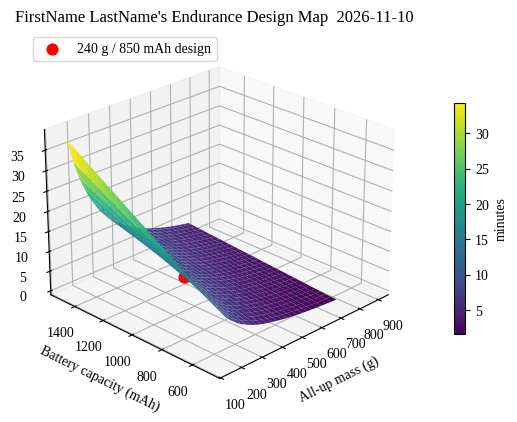

design point: 12.5 min ideal


In [11]:
d = data['PropA']                        # your chosen prop from above
thr, Tm, Im = d['throttle'], d['T_mean'], d['I_mean']

mass_g  = np.linspace(150, 900, 60)      # all-up mass candidates
cap_mAh = np.linspace(500, 1500, 60)     # battery candidates
M, C = np.meshgrid(mass_g, cap_mAh)      # 2-D grids: every combination

F_req   = M / 1000 * 9.81 / 4            # hover thrust per motor (N)
thr_req = np.interp(F_req, Tm, thr)      # throttle to hover, elementwise
I_req   = np.interp(thr_req, thr, Im)    # current at that throttle
t_fly   = C / 1000 / (4 * I_req) * 60    # ideal flight time (min)

t_fly[F_req > Tm.max()] = np.nan         # cannot hover: off the map

fig = plt.figure(figsize=(6.5, 5.0), facecolor='white')
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(M, C, t_fly, cmap='viridis', edgecolor='none')

# mark the Part-6 design point: 240 g, 850 mAh
t_pt = 0.850 / (4 * np.interp(np.interp(0.240*9.81/4, Tm, thr), thr, Im)) * 60
ax.scatter(240, 850, t_pt, s=60, c='red', depthshade=False,
           label='240 g / 850 mAh design')

ax.set_xlabel('All-up mass (g)')
ax.set_ylabel('Battery capacity (mAh)')
ax.set_zlabel('Ideal flight time (min)')
ax.set_title(f"FirstName LastName's Endurance Design Map  {date_str}")
ax.view_init(elev=25, azim=-135)
fig.colorbar(surf, shrink=0.6, pad=0.10, label='minutes')
ax.legend(loc='upper left')

fig.savefig('../Figures/FirstName_LastName_Lab09_EnduranceMap.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab09_EnduranceMap.pdf',
            bbox_inches='tight')
plt.show()
print(f"design point: {t_pt:.1f} min ideal")

## Grading / checking notes (TA)

- **Calibration**: c1 should land near 9.8–9.9 N/V (chain gain ~0.101 V/N),
  c0 near −0.88 N (it absorbs the tare + amp offset since the fit maps raw
  volts). s_yx of a few mN. Students who force the fit through zero have
  missed that the tare preloads the cell.
- **Tare handling**: thrust must be tare-corrected (subtract the motor-off
  reading). Forgetting it shifts every curve up by ~75 g — instantly visible.
- **Thrust at 70%**: PropA ≈ 185 g, PropB ≈ 220 g (±ε). CI half-widths
  ~2–6 g. If a student's CI is huge, they likely used ppf(0.95) or ddof=0…
  or mixed runs from different props.
- **Current**: reads ~0.2 A at zero throttle — that is ESC idle draw PLUS
  ACS712 offset error (true offset here is 2.5124 V, not 2.500). Good
  students will notice and discuss; it is intentionally in the data.
- **Momentum fit**: FM ≈ 0.4 (PropA slightly higher than PropB). Values
  above ~0.8 mean they compared against mechanical (not electrical) power
  or misused the disk area; values below 0.2 usually mean grams instead of
  newtons in T^1.5.
- **Design point**: PropA hovers near 37–39 % throttle at 60 g, ~1.0 A,
  margin ≈ 3x, flight time ~13–14 min ideal (students should note this
  ignores battery sag and hover inefficiency; accept 10–15 min with
  reasoning).
- **Endurance map**: surface should peak ~25–30 min at light mass / big
  battery, fall smoothly, and show a NaN cliff past ~740 g (where required
  thrust exceeds the 70% max). Design point ~12–13 min. A map with no
  cliff means they clipped instead of NaN-ing; a map that *rises* with
  mass means they inverted an interp. The physical caveat students should
  name (post-lab): bigger batteries weigh more — mass and capacity are
  coupled in a real design, so the top-left corner of this map is
  optimistic fiction.
- Common bugs: skipping `comments='#'`; using 0.185 V/A (that is the 5 A
  ACS712) instead of 0.100 V/A; grams/newtons mixups (check axis labels).